In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de datos y limpieza

In [2]:

dengue_zika_2018 = pd.read_csv("../data/raw/informacion-publica-dengue-zika-nacional-anio-2018.csv", sep=',')
# dengue_zika_2018 = dengue_zika_2018.rename(columns={"ano":"año"})

# dengue_zika = pd.concat([dengue_zika, dengue_zika_2018], ignore_index=True)
# dengue_zika

dengue_zika_2019 = pd.read_excel("../data/raw/informacion-publica-dengue-zika-nacional-anio-2019.xlsx")

dengue_zika_2020 = pd.read_excel("../data/raw/informacion-publica-dengue-zika-nacional-anio-2020.xlsx")


dengue_zika_2021 = pd.read_excel("../data/raw/informacion-publica-dengue-zika-nacional-anio-2021.xlsx")
# dengue_zika_2021

dengue_zika_2022 = pd.read_csv("../data/raw/informacion-publica-dengue-zika-nacional-anio-2022.csv", sep=';', encoding='mbcs')
# dengue_zika

dengue_zika_2024 = pd.read_csv("../data/raw/informacion-publica-dengue-zika-nacional-anio-2024.csv", sep=';', encoding='mbcs')
# dengue_zika_2024

dengue_zika_2025 = pd.read_csv("../data/raw/informacion-publica-dengue-zika-nacional-anio-2025.csv", sep=';', encoding='mbcs')
# dengue_zika_2025

dengue_zika_2023 = pd.read_csv("../data/raw/informacion-publica-dengue-zika-nacional-anio-2023.csv", sep=';')
                               # , encoding='mbcs')
# dengue_zika_2023

In [ ]:
print(dengue_zika_2018.columns)
print(dengue_zika_2019.columns)
print(dengue_zika_2020.columns)
print(dengue_zika_2021.columns)
print(dengue_zika_2022.columns)
print(dengue_zika_2023.columns)
print(dengue_zika_2024.columns)
print(dengue_zika_2025.columns)

In [4]:
print(dengue_zika_2018.shape)
print(dengue_zika_2019.shape)
print(dengue_zika_2020.shape)
print(dengue_zika_2021.shape)
print(dengue_zika_2022.shape)
print(dengue_zika_2023.shape)
print(dengue_zika_2024.shape)
print(dengue_zika_2025.shape)

(922, 10)
(1273, 10)
(11034, 10)
(1164, 10)
(293, 10)
(18228, 10)
(35168, 10)
(2925, 10)


In [3]:
dengue_zika_2023.rename(columns={"ï»¿id_depto_indec_residencia":"departamento_id",
                                 'departamento_residencia':'departamento_nombre',
                                'id_prov_indec_residencia':'provincia_id',
                                'provincia_residencia':'provincia_nombre',
                                'anio_min':'año', 'evento':'evento_nombre',
                                 'id_grupo_etario':'grupo_edad_id',
                                 'grupo_etario':'grupo_edad_desc',
                                 'cantidad':'cantidad_casos',
                                 'sepi_min':'semanas_epidemiologicas'
                                }, inplace = True)
dengue_zika_2024.rename(columns={"id_depto_indec_residencia":"departamento_id",
                                 'departamento_residencia':'departamento_nombre',
                                'id_prov_indec_residencia':'provincia_id',
                                'provincia_residencia':'provincia_nombre',
                                'anio_min':'año', 'evento':'evento_nombre',
                                 'id_grupo_etario':'grupo_edad_id',
                                 'grupo_etario':'grupo_edad_desc',
                                 'cantidad':'cantidad_casos',
                                 'sepi_min':'semanas_epidemiologicas'
                                }, inplace = True)

dengue_zika_2025.rename(columns={"ï»¿id_depto_indec_residencia":"departamento_id",
                                 'departamento_residencia':'departamento_nombre',
                                'id_prov_indec_residencia':'provincia_id',
                                'provincia_residencia':'provincia_nombre',
                                'anio_min':'año', 'evento':'evento_nombre',
                                 'id_grupo_etario':'grupo_edad_id',
                                 'grupo_etario':'grupo_edad_desc',
                                 'cantidad':'cantidad_casos',
                                 'sepi_min':'semanas_epidemiologicas'
                                }, inplace = True)

dengue_zika_2018.rename(columns={"ano":"año"}, inplace = True)

In [4]:
dengue_zika = pd.concat([dengue_zika_2018, dengue_zika_2019, dengue_zika_2020,
                         dengue_zika_2021, dengue_zika_2022, dengue_zika_2023,
                         dengue_zika_2024, dengue_zika_2025])

In [5]:
dengue_zika.shape

(71007, 11)

In [6]:
dengue_zika[dengue_zika['grupo_edad_id'].isna()]

,departamento_id,departamento_nombre,provincia_id,provincia_nombre,año,semanas_epidemiologicas,evento_nombre,grupo_edad_id,grupo_edad_desc,cantidad_casos,id_depto_indec_residencia
127,22063,General Guemes,22,Chaco,2019.0,20,Dengue,NaN,Sin Especificar,2.0,NaN
645,66007,Anta,66,Salta,2019.0,13,Dengue,NaN,Sin Especificar,1.0,NaN
35167,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Remuevo valores nulos
dengue_zika.dropna(subset="grupo_edad_id", inplace=True)

In [8]:
dengue_zika.shape


(71004, 11)

### Grupos de edad: mal cargados

In [9]:
tabla_aux = dengue_zika[dengue_zika["grupo_edad_desc"].isin(range(0,12))]
# Hay un paquete de filas que tienen los datos invertidos
tabla_aux.rename(columns={'grupo_edad_id':'grupo_edad_desc', 
                          'grupo_edad_desc':'grupo_edad_id'}, inplace=True)
# dengue_zika["grupo_edad_desc"].value_counts()

# Elimino datos mal cargados
lista_a_borrar = dengue_zika["grupo_edad_desc"].isin(range(0,12))
dengue_zika = dengue_zika[~lista_a_borrar]

C:\Users\mbustos_lightech\AppData\Local\Temp\ipykernel_3568\337286791.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla_aux.rename(columns={'grupo_edad_id':'grupo_edad_desc',


In [10]:
# Adiciono la lista con los nombres correctos
dengue_zika_df = pd.concat([dengue_zika,tabla_aux])

In [11]:
dengue_zika_df.shape

(71004, 11)

In [12]:
dengue_df = dengue_zika_df[dengue_zika_df["semanas_epidemiologicas"] == "Dengue "]

In [13]:
dengue_df.shape

(1115, 11)

In [14]:
# Hay un paquete de filas que tienen los datos invertidos
dengue_df.rename(columns={'semanas_epidemiologicas':'evento_nombre', 
                          'evento_nombre':'semanas_epidemiologicas', 
                          'grupo_edad_id':'grupo_edad_desc', 
                          'grupo_edad_desc':'grupo_edad_id'}, inplace=True)

C:\Users\mbustos_lightech\AppData\Local\Temp\ipykernel_3568\1660014259.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dengue_df.rename(columns={'semanas_epidemiologicas':'evento_nombre',


In [15]:
dengue_df.shape

(1115, 11)

In [16]:
dengue_df["evento_nombre"] = "Dengue"

C:\Users\mbustos_lightech\AppData\Local\Temp\ipykernel_3568\673317918.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dengue_df["evento_nombre"] = "Dengue"


In [17]:
# Elimino datos mal cargados
lista_a_borrar = dengue_zika_df["semanas_epidemiologicas"] == "Dengue "
dengue_zika_df = dengue_zika_df[~lista_a_borrar]


In [18]:
dengue_zika_df.shape

(69889, 11)

In [19]:
# Adiciono la lista con los nombres correctos
dengue_zika_df = pd.concat([dengue_zika_df,dengue_df])

dengue_zika_df.shape

(71004, 11)

### Provincias: Datos mal cargados

In [20]:
# Provincias: Datos mal cargados
tabla_aux = dengue_zika_df[dengue_zika_df["provincia_nombre"].isin(range(0,100))]

# Hay un paquete de filas que tienen los datos invertidos
tabla_aux.rename(columns={'provincia_nombre':'provincia_id', 
                          'provincia_id':'provincia_nombre'}, inplace=True)

# Elimino datos mal cargados
lista_a_borrar = dengue_zika_df["provincia_nombre"].isin(range(0,100))
dengue_zika_df = dengue_zika_df[~lista_a_borrar]

C:\Users\mbustos_lightech\AppData\Local\Temp\ipykernel_3568\803712620.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tabla_aux.rename(columns={'provincia_nombre':'provincia_id',


In [21]:
# Adiciono la lista con los nombres correctos
dengue_zika_df = pd.concat([dengue_zika_df,tabla_aux])

dengue_zika_df.shape

(71004, 11)

### Estandarizar los nombres

#### Grupo etario

In [22]:
dengue_zika_df["grupo_edad_desc"] = dengue_zika_df.grupo_edad_desc.str.capitalize()
# dengue_zika_df.grupo_edad_desc.str.capitalize()

dengue_zika_df["grupo_edad_desc"] = dengue_zika_df.grupo_edad_desc.str.replace("ano", "año")

dengue_zika_df["grupo_edad_desc"] = dengue_zika_df.grupo_edad_desc.str.replace("dÍas", "días")
dengue_zika_df["grupo_edad_desc"] = dengue_zika_df.grupo_edad_desc.str.replace("dias", "días")
dengue_zika_df["grupo_edad_desc"] = dengue_zika_df.grupo_edad_desc.str.replace("(de 29 a 365 días)", "(29 hasta 365 días)")
# dengue_zika_df["grupo_edad_desc"] = dengue_zika_df.grupo_edad_desc.str.replace("(29 a 365 días)", "(29 hasta 365 dias)")

dengue_zika_df["grupo_edad_desc"] = dengue_zika_df.grupo_edad_desc.str.replace("Mayor de  65 años", "Mayores de 65 años")
dengue_zika_df["grupo_edad_desc"] = dengue_zika_df.grupo_edad_desc.str.replace("Mayor o igual de 65 años", "Mayores de 65 años")

dengue_zika_df["grupo_edad_desc"] = dengue_zika_df.grupo_edad_desc.str.replace("Edad sin esp.", "Sin especificar")
dengue_zika_df["grupo_edad_desc"] = dengue_zika_df.grupo_edad_desc.str.replace("-", "Sin especificar")


In [23]:
dengue_zika_df["grupo_edad_desc"].value_counts()

grupo_edad_desc
De 45 a 65 años                   10532
De 25 a 34 años                   10372
De 35 a 44 años                    9540
De 20 a 24 años                    7847
De 15 a 19 años                    7215
De 10 a 14 años                    6622
Mayores de 65 años                 6433
De 5 a 9 años                      5412
De 2 a 4 años                      2970
De 13 a 24 meses                   1286
Posneonato (29 hasta 365 días)     1249
Neonato (hasta 28 días)             199
Sin especificar                      94
De 45 a 64 años                      76
De 15 a 24 años                      58
Menor que 1 año                       4
Igual a 1 año                         2
Name: count, dtype: int64

#### Provincia

In [24]:
dengue_zika_df["provincia_nombre"] = dengue_zika_df.provincia_nombre.str.replace("desconocida", "Sin especificar")
dengue_zika_df["provincia_nombre"] = dengue_zika_df.provincia_nombre.str.replace("(en blanco)", "Sin especificar")
dengue_zika_df["provincia_nombre"] = dengue_zika_df.provincia_nombre.str.replace("DESCONOCIDA", "Sin especificar")
dengue_zika_df["provincia_nombre"] = dengue_zika_df.provincia_nombre.str.replace("*sin dato*", "Sin especificar")
dengue_zika_df["provincia_nombre"] = dengue_zika_df.provincia_nombre.str.replace("SAnta Fe", "Santa Fe")
dengue_zika_df["provincia_nombre"] = dengue_zika_df.provincia_nombre.str.replace("SAnta Cruz", "Santa Cruz")
# dengue_zika_df["provincia_nombre"] = dengue_zika_df.provincia_nombre.str.replace("Edad sin esp.", "Sin especificar")
# dengue_zika_df["provincia_nombre"] = dengue_zika_df.provincia_nombre.str.replace("-", "Sin especificar")


### Casteo

In [25]:
dengue_zika_df['grupo_edad_desc'] = dengue_zika_df['grupo_edad_desc'].astype("str")
dengue_zika_df['cantidad_casos'] = dengue_zika_df['cantidad_casos'].astype("int32")
dengue_zika_df['año'] = dengue_zika_df['año'].astype("int32")
dengue_zika_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71004 entries, 0 to 1163
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   departamento_id            49851 non-null  object 
 1   departamento_nombre        71004 non-null  object 
 2   provincia_id               71004 non-null  object 
 3   provincia_nombre           71004 non-null  object 
 4   año                        71004 non-null  int32  
 5   semanas_epidemiologicas    71004 non-null  object 
 6   evento_nombre              71004 non-null  object 
 7   grupo_edad_id              71004 non-null  object 
 8   grupo_edad_desc            71004 non-null  object 
 9   cantidad_casos             71004 non-null  int32  
 10  id_depto_indec_residencia  21153 non-null  float64
dtypes: float64(1), int32(2), object(8)
memory usage: 6.0+ MB


In [26]:
import os

In [30]:
print(os.getcwd())

C:\Users\mbustos_lightech\Documents\Python Scripts\Contar con datos\dengue_y_zika\notebooks


In [32]:
dengue_zika_df.to_csv("..//data//preprocessed/dengue_zika_2018-2025", index=False)

# Zika VS Dengue

### Distribución por provincia

In [33]:
dengue_zika_df["provincia_nombre"].value_counts()

provincia_nombre
Buenos Aires           11768
Chaco                   8099
Santa Fe                5705
Tucumán                 5583
Salta                   5298
Córdoba                 5206
CABA                    4986
Misiones                4236
Formosa                 3512
Santiago del Estero     2888
Corrientes              2827
Entre Ríos              2209
Jujuy                   2193
Catamarca               1467
La Rioja                1330
Mendoza                  754
Sin especificar          650
San Juan                 636
San Luis                 566
La Pampa                 356
Santa Cruz               249
Neuquén                  165
Tierra del Fuego         158
Río Negro                 93
Chubut                    70
Name: count, dtype: int64

In [7]:
dengue_zika[dengue_zika["provincia_nombre"] == "Buenos Aires"].groupby("departamento_nombre").count()

,departamento_id,provincia_id,provincia_nombre,año,semanas_epidemiologicas,evento_nombre,grupo_edad_id,grupo_edad_desc,cantidad_casos
departamento_nombre,,,,,,,,,
Almirante Brown,4,4,4,4,4,4,4,4,4
Avellaneda,39,39,39,39,39,39,39,39,39
Berazategui,4,4,4,4,4,4,4,4,4
DESCONOCIDO,1,1,1,1,1,1,1,1,1
Ensenada,1,1,1,1,1,1,1,1,1
Escobar,1,1,1,1,1,1,1,1,1
Esteban Echeverría,1,1,1,1,1,1,1,1,1
Ezeiza,5,5,5,5,5,5,5,5,5
Florencio Varela,3,3,3,3,3,3,3,3,3


### Distribución según la cantidad de casos registrados

In [58]:
dengue_zika_df["cantidad_casos"].describe()

count    68774.000000
mean        11.304228
std         42.052554
min          1.000000
25%          1.000000
50%          2.000000
75%          7.000000
max       2101.000000
Name: cantidad_casos, dtype: float64

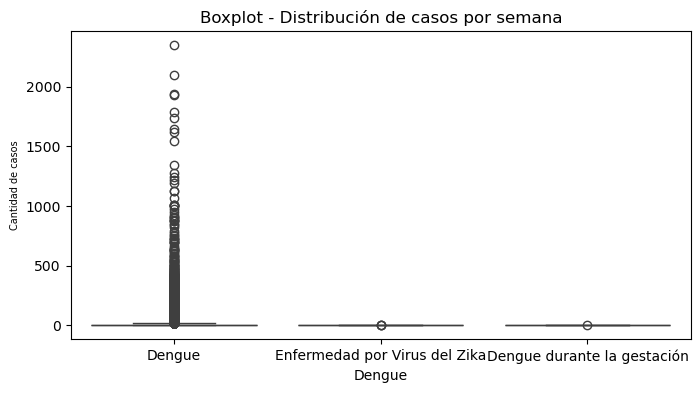

In [139]:
datos = dengue_zika_df
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
sns.boxplot(x="evento_nombre" , y="cantidad_casos",data=datos, ax=ax)
ax.set_title("Boxplot - Distribución de casos por semana")
ax.set_xlabel(xlabel="Dengue", size=10)
ax.set_ylabel(ylabel="Cantidad de casos" , size=7)
plt.show()

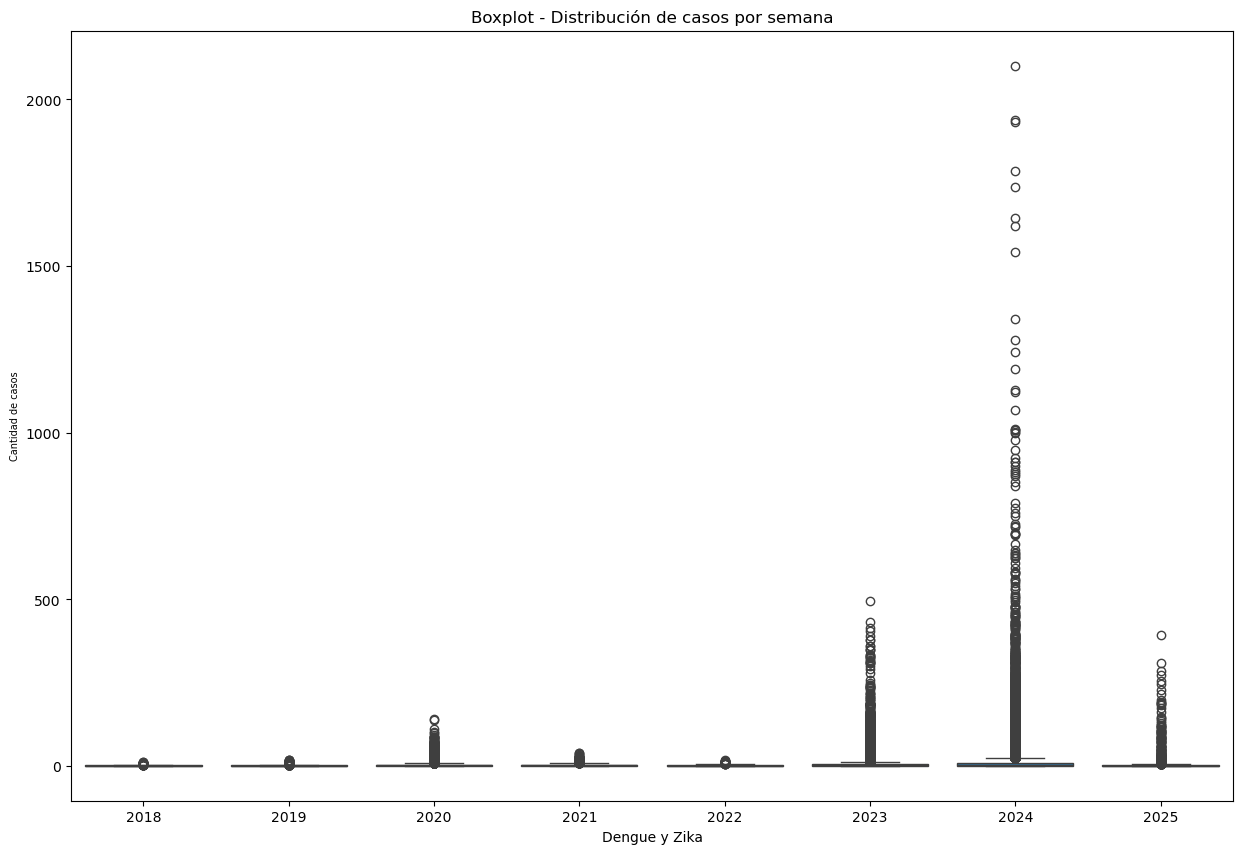

In [51]:
datos = dengue_zika
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
sns.boxplot(x="año", y="cantidad_casos", data=datos, ax=ax)
# sns.swarmplot(x="año", y="cantidad_casos", data=datos, color='black', alpha=0.5, ax=ax);
ax.set_title("Boxplot - Distribución de casos por semana")
ax.set_xlabel(xlabel="Dengue y Zika", size=10)
ax.set_ylabel(ylabel="Cantidad de casos" , size=7)
plt.show()

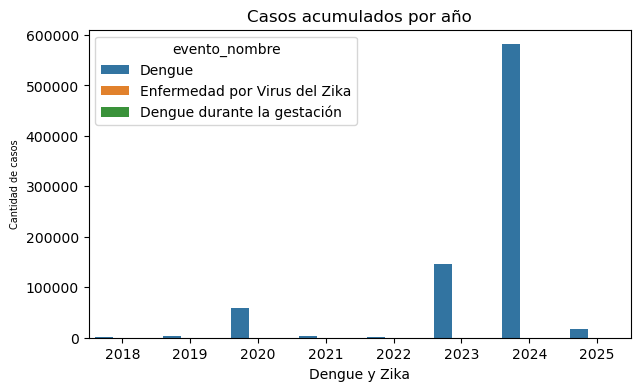

In [43]:
datos = dengue_zika_df
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
# datos.plot(kind="bar", x="año", y="cantidad_casos", ax=ax)
sns.barplot(datos, x="año", y="cantidad_casos", estimator="sum", errorbar=None, hue="evento_nombre", ax=ax)
# sns.swarmplot(x="año", y="cantidad_casos", data=datos, color='black', alpha=0.5, ax=ax);
ax.set_title("Incidencia anual")
ax.set_xlabel(xlabel="Dengue y Zika", size=10)
ax.set_ylabel(ylabel="Cantidad de casos" , size=7)
plt.show()

In [72]:
dengue_zika_df.groupby("año")["cantidad_casos"].sum()

año
2018      1613
2019      2791
2020     58766
2021      3991
2022       802
2023    146876
2024    581433
2025     16819
Name: cantidad_casos, dtype: int32

In [73]:
datos_2018 = dengue_zika_df[dengue_zika_df["año"] == 2018]
datos_2019 = dengue_zika_df[dengue_zika_df["año"] == 2019]
datos_2020 = dengue_zika_df[dengue_zika_df["año"] == 2020]
datos_2021 = dengue_zika_df[dengue_zika_df["año"] == 2021]
datos_2022 = dengue_zika_df[dengue_zika_df["año"] == 2022]
datos_2023 = dengue_zika_df[dengue_zika_df["año"] == 2023]
datos_2024 = dengue_zika_df[dengue_zika_df["año"] == 2024]
datos_2025 = dengue_zika_df[dengue_zika_df["año"] == 2025]

In [88]:
dato_X_año = list([datos_2018,datos_2019,datos_2020,datos_2021,datos_2022,
                   datos_2023,datos_2024,datos_2025])

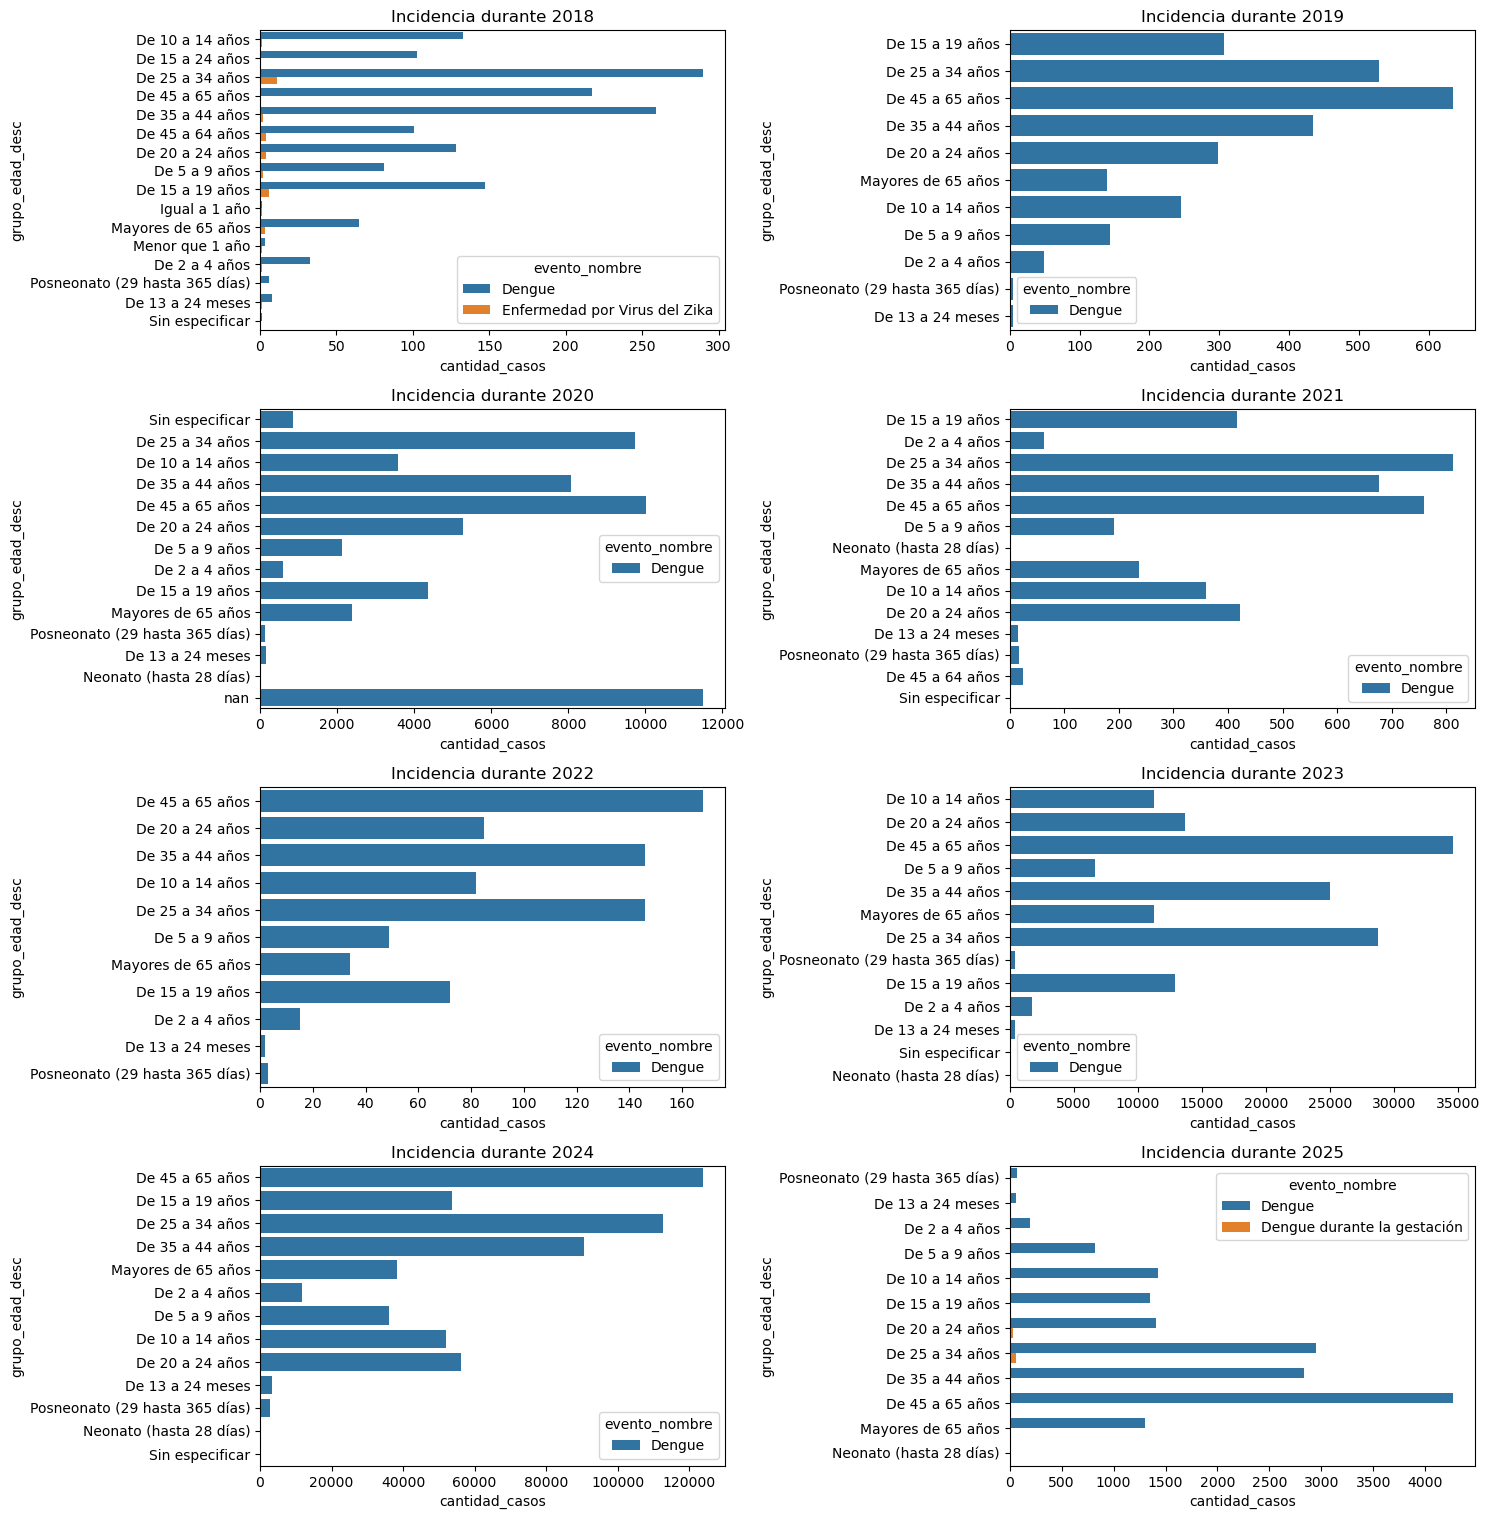

In [111]:
# Grafico de distribución
list_año = list(range(2017,2026))

plt.figure(figsize=(15,30))
for i, año in enumerate(dato_X_año,1):
# fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    plt.subplot(8, 2, i)
# datos.plot(kind="bar", x="año", y="cantidad_casos", ax=ax)
    sns.barplot(año, y="grupo_edad_desc", x="cantidad_casos", estimator="sum", errorbar=None, hue="evento_nombre")
    plt.tight_layout()
# sns.swarmplot(x="año", y="cantidad_casos", data=datos, color='black', alpha=0.5, ax=ax);
    plt.title(f"Incidencia durante {list_año[i]}")
    
# ax.set_xlabel(xlabel="Dengue y Zika", size=10)
# ax.set_ylabel(ylabel="Cantidad de casos" , size=7)
plt.show()

In [ ]:
dengue_zika[dengue_zika["cantidad_casos"] > 5]

## Distribución por semana

Identifica que época del año tiene más o menos contagios.